# LangChain Agents Bootcamp - Financial Analysis with Gemini

Complete guide to building production-ready agents with memory, middleware, and streaming.

https://docs.langchain.com/oss/python/langchain/middleware/built-in

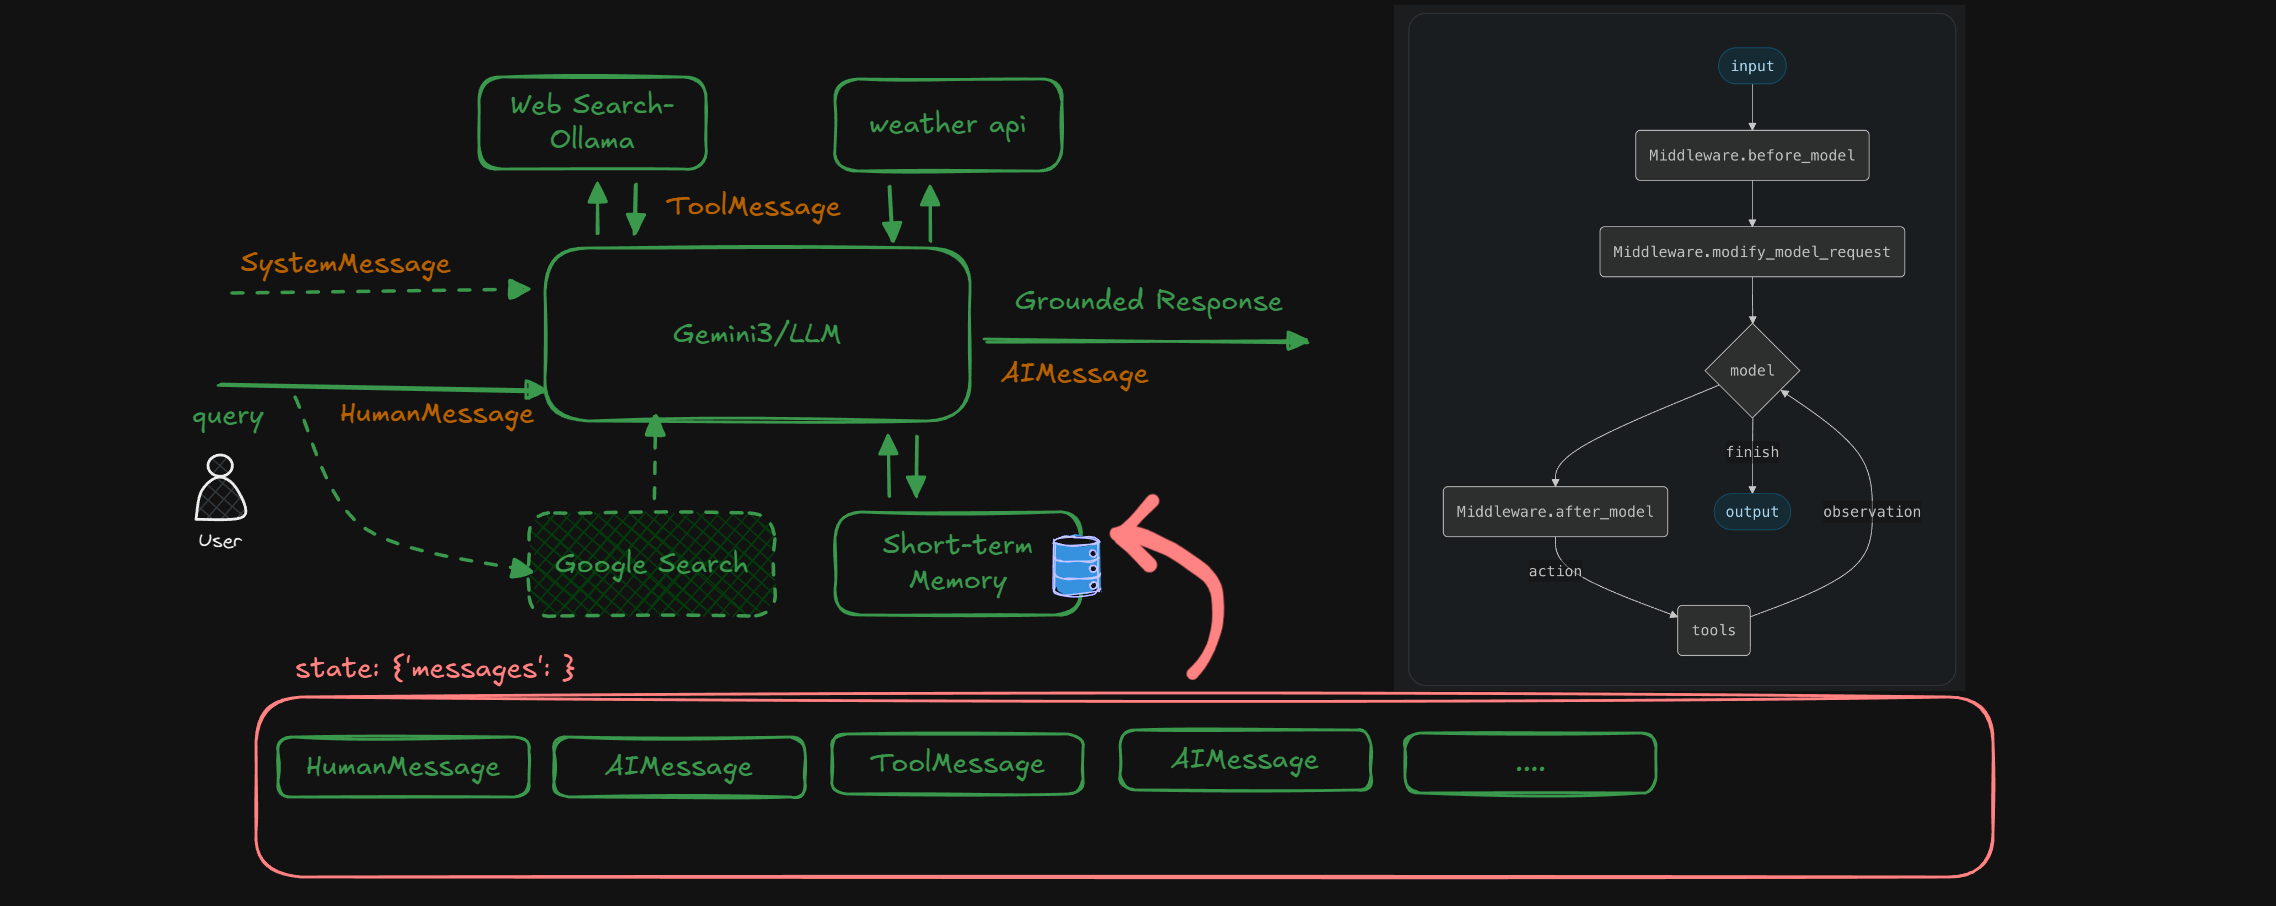

## Overview

This notebook covers:
- **Short-term Memory**: Persist conversation state with SQLite
- **Built-in Middleware**: Production patterns (summarization, limits, PII detection, todo tracking)
- **Structured Output**: Type-safe agent responses with Pydantic
- **Streaming Modes**: Real-time updates (`messages`, `updates`, `values`)

## Setup

Initialize model and tools for financial analysis.

In [1]:
from langfuse.langchain import CallbackHandler

from dotenv import load_dotenv
load_dotenv()

langfuse_handler = CallbackHandler()

In [2]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.agents import create_agent
from langchain.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage
from scripts import base_tools

In [3]:
# model = ChatGoogleGenerativeAI(model="gemini-2.5-flash") # gemini-3-pro-preview
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite") # gemini-3-pro-preview

In [4]:
system_prompt = "You are a financial analyst specializing in tech stocks.\nProvide data-driven analysis with clear insights. you have access to web_search tools and get_weather tools."

## 1. Basic Agent

Create a simple agent with tools but no memory.

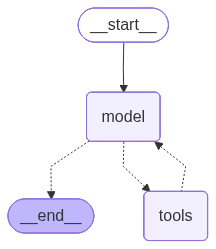

In [5]:
agent = create_agent(
    model=model,
    tools=[base_tools.web_search, base_tools.get_weather],
    system_prompt=system_prompt
)
agent

In [6]:
query = "what's apple's current stock price?"
response = agent.invoke(
    {
        "messages": [HumanMessage(query)]
    },
    config={"callbacks": [langfuse_handler]}
)

In [7]:
response
# response["messages"][-1].content

{'messages': [HumanMessage(content="what's apple's current stock price?", additional_kwargs={}, response_metadata={}, id='cdd42b8c-79c7-4795-afbd-a69d95765c39'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'web_search', 'arguments': '{"query": "Apple stock price"}'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019eb497-8c3d-7c70-8b79-79b3822c8e97-0', tool_calls=[{'name': 'web_search', 'args': {'query': 'Apple stock price'}, 'id': 'a2bcbce2-dd64-4421-bc36-3305d691bd0e', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 246, 'output_tokens': 17, 'total_tokens': 263, 'input_token_details': {'cache_read': 0}}),
  ToolMessage(content="[WebSearchResult(content='Stock Price - Apple\\n\\nSkip to main content\\n\\n# Stock Price\\n\\n## Stock Price\\n\\nJune 10, 2026 12:02 p.m. ET\\n\\nThe stock information provided is for informational

In [ ]:
query = "what's apple's current stock price? and what is the latest weather in Mumbai?"
response = agent.invoke({'messages': [HumanMessage(query)]})

In [ ]:
print(response)
print(response["messages"][1].tool_calls)

In [ ]:
print(response['messages'][-1].text)

## 2. Short-term Memory with SQLite

Add conversation persistence using SQLite checkpointer. Agent remembers previous turns within a session.

In [8]:
from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3

In [9]:
conn = sqlite3.connect("data/financial_agent.db", check_same_thread=False)
checkpointer = SqliteSaver(conn=conn)

In [10]:
agent_memory = create_agent(
    model=model,
    tools=[base_tools.web_search, base_tools.get_weather],
    system_prompt=system_prompt,
    checkpointer=checkpointer,
)

In [ ]:
config = {
    "callbacks:": [langfuse_handler],
    "configurable": {
        "thread_id": "memory_session",
    },
}
response = agent_memory.invoke({'messages': [query]}, config=config)

In [16]:
response

{'messages': [HumanMessage(content="what's apple's current stock price?", additional_kwargs={}, response_metadata={}, id='0f0b240b-eff1-4a1c-8713-293413c27515'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'web_search', 'arguments': '{"query": "apple stock price"}'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019eb4b8-39c8-71c1-aed7-d37eca4848d7-0', tool_calls=[{'name': 'web_search', 'args': {'query': 'apple stock price'}, 'id': '2f2f140c-fe47-4824-9b34-45c341f28efa', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 246, 'output_tokens': 17, 'total_tokens': 263, 'input_token_details': {'cache_read': 0}}),
  ToolMessage(content="[WebSearchResult(content='Stock Price - Apple\\n\\nSkip to main content\\n\\n# Stock Price\\n\\n## Stock Price\\n\\nJune 10, 2026 12:02 p.m. ET\\n\\nThe stock information provided is for informational

In [17]:
response = agent_memory.invoke({'messages': ["what is the latest US stock news"]}, config=config)

In [18]:
response

{'messages': [HumanMessage(content="what's apple's current stock price?", additional_kwargs={}, response_metadata={}, id='0f0b240b-eff1-4a1c-8713-293413c27515'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'web_search', 'arguments': '{"query": "apple stock price"}'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019eb4b8-39c8-71c1-aed7-d37eca4848d7-0', tool_calls=[{'name': 'web_search', 'args': {'query': 'apple stock price'}, 'id': '2f2f140c-fe47-4824-9b34-45c341f28efa', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 246, 'output_tokens': 17, 'total_tokens': 263, 'input_token_details': {'cache_read': 0}}),
  ToolMessage(content="[WebSearchResult(content='Stock Price - Apple\\n\\nSkip to main content\\n\\n# Stock Price\\n\\n## Stock Price\\n\\nJune 10, 2026 12:02 p.m. ET\\n\\nThe stock information provided is for informational

In [19]:
for res in response['messages']:
    if isinstance(res, AIMessage):
        print(res.usage_metadata)

{'input_tokens': 246, 'output_tokens': 17, 'total_tokens': 263, 'input_token_details': {'cache_read': 0}}
{'input_tokens': 727, 'output_tokens': 18, 'total_tokens': 745, 'input_token_details': {'cache_read': 0}}
{'input_tokens': 17879, 'output_tokens': 108, 'total_tokens': 17987, 'input_token_details': {'cache_read': 0}}
{'input_tokens': 17996, 'output_tokens': 19, 'total_tokens': 18015, 'input_token_details': {'cache_read': 0}}
{'input_tokens': 19762, 'output_tokens': 250, 'total_tokens': 20012, 'input_token_details': {'cache_read': 0}}
{'input_tokens': 20021, 'output_tokens': 19, 'total_tokens': 20040, 'input_token_details': {'cache_read': 0}}
{'input_tokens': 21787, 'output_tokens': 250, 'total_tokens': 22037, 'input_token_details': {'cache_read': 0}}


## Built-in Middleware

## 3. Middleware: Summarization

Automatically summarize old messages when history grows too long.

**Use Case**: Long conversations that exceed context windows.

In [22]:
from langchain.agents.middleware import SummarizationMiddleware

In [29]:
GEMINI_MODEL = "gemini-2.5-flash"
# GEMINI_MODEL = "gemini-2.5-flash-lite"

In [30]:
agent_summary = create_agent(
    model=model,
    tools=[base_tools.web_search, base_tools.get_weather],
    system_prompt=system_prompt,
    checkpointer=checkpointer,
    middleware=[
        SummarizationMiddleware(
            model=ChatGoogleGenerativeAI(model=GEMINI_MODEL),
            trigger=[("messages", 10)],
            keep=("messages", 5)
        )
    ]
)

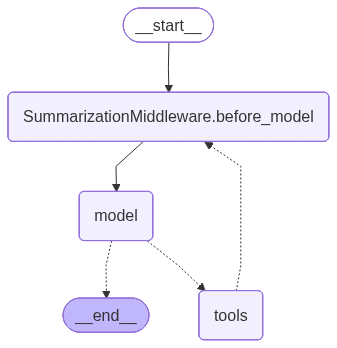

In [31]:
agent_summary

In [32]:
message = """
what is the stock price of Microsoft and Apple. What is the latest weather in Mumbai. 
What is the latest news on Vietnam Stock market?. Use the web search tool.
"""

In [33]:
response = agent_summary.invoke(
    {'messages': [message]},
    config=config
)

In [34]:
response

{'messages': [HumanMessage(content="Here is a summary of the conversation to date:\n\n## SESSION INTENT\nThe user's primary goal is to obtain the stock prices of Microsoft and Apple, the latest weather in Mumbai, and the latest news on the Vietnam stock market.\n\n## SUMMARY\nIn the previous turn, the requested information was successfully retrieved and presented to the user:\n*   **Microsoft (MSFT) stock price:** $397.36 (down 1.50%) as of June 10, 2026.\n*   **Apple (AAPL) stock price:** $291.41 (up $0.86) as of June 10, 2026.\n*   **Weather in Mumbai:** Mist, 33.1°C (91.6°F), 63% humidity, wind W at 20.9 km/h (13 mph).\n*   **Latest Asian Stock Market News:** Asian markets declined due to tech selloff and escalating Middle East tensions (US strikes on Iran), leading to rising crude oil prices. Investors are focused on upcoming US inflation data. The MSCI Asia Pacific Index fell 0.5%, with Kospi and Nikkei also declining.\nThe user has now re-requested the Microsoft and Apple stock p

In [35]:
response['messages'][0].pretty_print()

================================ Human Message =================================

Here is a summary of the conversation to date:

## SESSION INTENT
The user's primary goal is to obtain the stock prices of Microsoft and Apple, the latest weather in Mumbai, and the latest news on the Vietnam stock market.

## SUMMARY
In the previous turn, the requested information was successfully retrieved and presented to the user:
*   **Microsoft (MSFT) stock price:** $397.36 (down 1.50%) as of June 10, 2026.
*   **Apple (AAPL) stock price:** $291.41 (up $0.86) as of June 10, 2026.
*   **Weather in Mumbai:** Mist, 33.1°C (91.6°F), 63% humidity, wind W at 20.9 km/h (13 mph).
*   **Latest Asian Stock Market News:** Asian markets declined due to tech selloff and escalating Middle East tensions (US strikes on Iran), leading to rising crude oil prices. Investors are focused on upcoming US inflation data. The MSCI Asia Pacific Index fell 0.5%, with Kospi and Nikkei also declining.
The user has now re-reques

In [36]:
response['messages'][-1].text

"Microsoft's stock price is $404.52 as of June 10, 2026, 04:00:00 PM - ET. Apple's stock price is $291.41 with a change of +$0.86 as of June 10, 2026, 12:02 p.m. ET. The weather in Mumbai is Mist with a temperature of 33.3°C (91.9°F), 63% humidity, and wind W at 20.9 km/h (13 mph).\n\nVietnam's stock market experienced a sharp decline on June 8, 2026, with the VN-Index falling by almost 2.2% and the HNX-Index losing nearly 3.2%. This downturn mirrored a global sell-off across Asian markets, including South Korea's Kospi, Japan's Nikkei 225, Hong Kong's Hang Seng Index, and China's CSI 300. The sell-off was triggered by a stronger-than-expected US employment report, which fueled concerns about prolonged high interest rates. Geopolitical tensions, particularly concerning Iran, also added to market uncertainty. Investors are now closely watching upcoming US inflation data."

In [ ]:
response

## 4. Middleware: Model and Tool Call Limit

Limit the number of model calls per request to prevent runaway costs.

**Exit Behaviors**: `"end"` (stop) or `"continue"` (proceed without model)

In [37]:
from langchain.agents.middleware import ModelCallLimitMiddleware
from langchain.agents.middleware import ToolCallLimitMiddleware
from langchain.agents.middleware import ModelFallbackMiddleware

In [ ]:
agent_limit = create_agent(
    model=model,
    tools=[base_tools.web_search, base_tools.get_weather],
    system_prompt=system_prompt,
    checkpointer=checkpointer,
    middleware=[
        SummarizationMiddleware(
            model=ChatGoogleGenerativeAI(model='gemini-2.5-flash'),
            trigger=[("messages", 15)],
            keep=("messages", 5)
        ),
        ModelCallLimitMiddleware(run_limit=2, exit_behavior="end"),
        ToolCallLimitMiddleware(run_limit=2, exit_behavior='continue'),
        ModelFallbackMiddleware(ChatGoogleGenerativeAI(model='gemini-3-pro-preview'))
    ]
)

In [39]:
config = {'configurable': {'thread_id': 'limit_session'}, 'callbacks': [langfuse_handler]}
response = agent_limit.invoke({'messages': ['what is the total distance between earth and moon. what is the latest news on trump. what is the latest weather of London?']}, config)


In [40]:
response

{'messages': [HumanMessage(content='what is the total distance between earth and moon. what is the latest news on trump. what is the latest weather of London?', additional_kwargs={}, response_metadata={}, id='2368a0b8-5fc7-458e-bc04-0cacd09cf85e'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'get_weather', 'arguments': '{"location": "London"}'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019eb4e2-2f19-72d1-a3eb-912ff65da7bb-0', tool_calls=[{'name': 'web_search', 'args': {'query': 'distance between earth and moon'}, 'id': 'c511804b-f042-4dac-bdb3-020f0d3bb47b', 'type': 'tool_call'}, {'name': 'web_search', 'args': {'query': 'latest news on trump'}, 'id': '9d5f8255-a8c3-402e-aef6-2a199c69d131', 'type': 'tool_call'}, {'name': 'get_weather', 'args': {'location': 'London'}, 'id': 'bd8e8f3d-f0a5-40e6-a6f0-5c0b2a0d80a7', 'type': 'tool_call'}], invalid_tool_call

In [41]:
response = agent_limit.invoke({'messages': ['tell me 3 facts about the earth']}, config)
response

{'messages': [HumanMessage(content='what is the total distance between earth and moon. what is the latest news on trump. what is the latest weather of London?', additional_kwargs={}, response_metadata={}, id='2368a0b8-5fc7-458e-bc04-0cacd09cf85e'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'get_weather', 'arguments': '{"location": "London"}'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019eb4e2-2f19-72d1-a3eb-912ff65da7bb-0', tool_calls=[{'name': 'web_search', 'args': {'query': 'distance between earth and moon'}, 'id': 'c511804b-f042-4dac-bdb3-020f0d3bb47b', 'type': 'tool_call'}, {'name': 'web_search', 'args': {'query': 'latest news on trump'}, 'id': '9d5f8255-a8c3-402e-aef6-2a199c69d131', 'type': 'tool_call'}, {'name': 'get_weather', 'args': {'location': 'London'}, 'id': 'bd8e8f3d-f0a5-40e6-a6f0-5c0b2a0d80a7', 'type': 'tool_call'}], invalid_tool_call

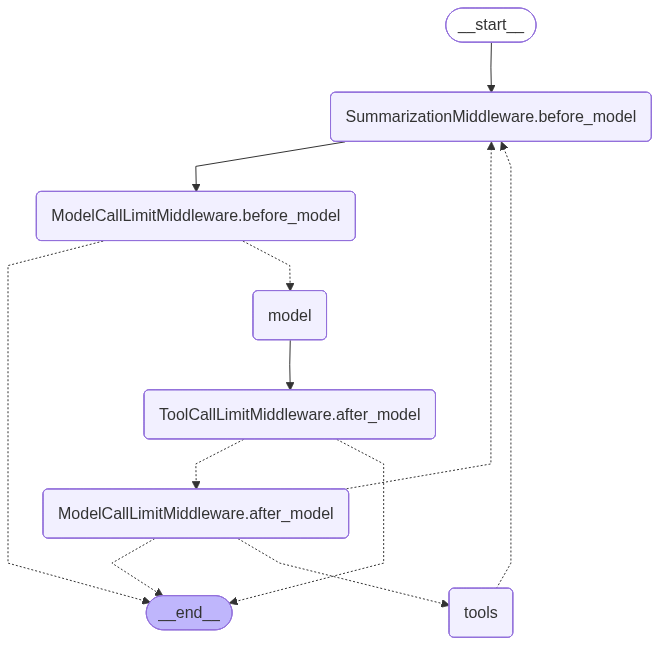

In [42]:
agent_limit

## 5. Middleware: Guardrails and PII Detection

Automatically detect and redact/mask personally identifiable information.

**Strategies**: `"redact"` (remove), `"mask"` (replace with ***), `"block"` (prevent request)

In [ ]:
from langchain.agents.middleware import PIIMiddleware


In [ ]:
agent_pii = create_agent(
    model=model,
    tools=[base_tools.web_search, base_tools.get_weather],
    system_prompt=system_prompt,
    checkpointer=checkpointer,
    middleware=[
        PIIMiddleware("api_key", detector=r"sk-[a-zA-Z0-9]{32}", strategy="block"),
        PIIMiddleware("email", strategy="redact", apply_to_input=True),
        PIIMiddleware("credit_card", strategy="mask", apply_to_input=True),
        PIIMiddleware("url", strategy="redact", apply_to_input=True)
    ])

In [ ]:
config = {'configurable': {'thread_id': 'pii_session'}}

response = agent_pii.invoke({'messages': [HumanMessage('Hi, my name is laxmi kant. here is my email info@kgptalkie.com')]}, config=config)

In [ ]:
response

In [ ]:
response = agent_pii.invoke({'messages': 
                             [HumanMessage('Hi, my name is laxmi kant. here is my email info@kgptalkie.com. my website is https://kgptalkie.com')]}, config=config)

In [ ]:
response

## 6. Middleware: Todo List

Track and manage multi-step tasks within the agent.

In [ ]:
from langchain.agents.middleware import TodoListMiddleware

In [ ]:
system_prompt

In [ ]:
agent_todo = create_agent(
    model=model,
    tools=[base_tools.web_search, base_tools.get_weather],
    system_prompt=system_prompt,
    checkpointer=checkpointer,
    middleware=[TodoListMiddleware()]
)

In [ ]:
config = {'configurable': {'thread_id': 'todo_session_1'}}

response = agent_todo.invoke(
    {'messages': [HumanMessage("analyze the apple revenue and compare it with competitors")]},
    config=config
)

In [ ]:
response

In [ ]:
print(response['messages'][-1].text)

## 7. Streaming: Messages Mode
Three streaming modes for real-time agent updates:
- **`messages`**: Stream individual messages as they're generated
- **`updates`**: Stream state updates after each step
- **`values`**: Stream complete state values

In [ ]:
config = {'configurable': {'thread_id': 'stream_session'}}
for chunk in agent.stream({'messages':['tell me about the apple news']}, stream_mode='messages', config=config):
    print(chunk)
    print("------\n")

In [ ]:
config = {'configurable': {'thread_id': 'stream_session_1'}}
for chunk in agent.stream({'messages':['tell me about the apple news']}, stream_mode='updates', config=config):
    print(chunk)
    print("------\n")

In [ ]:
config = {'configurable': {'thread_id': 'stream_session_2'}}
for chunk in agent.stream({'messages':['tell me about the apple news']}, stream_mode='values', config=config):
    print(chunk)
    print("------\n")

In [ ]:
agent

## 8. Structured Output

Return type-safe Pydantic models from agent responses.

In [ ]:
from pydantic import BaseModel, Field
from typing import Optional

In [ ]:
class FinancialAnalysis(BaseModel):
    company: str = Field (description="Company Name")
    stock_symbol: str = Field (description="Company Stock Symbol")
    current_price: Optional[str] = Field (description="Company's current stock price")
    analysis: str = Field (description="Company's brief analysis")
    recommendation: str = Field (description="What is recommendation? Buy/Hold/Sell")

In [ ]:
agent = create_agent(
    model=model,
    tools=[base_tools.web_search, base_tools.get_weather],
    system_prompt=system_prompt,
    response_format = FinancialAnalysis
)

In [ ]:
response = agent.invoke({'messages': [HumanMessage('Analyze the apple stock')]})

In [ ]:
response

In [ ]:
response['structured_response'].model_dump()